# <center><span style='color:red'><b>EOF (without normalisation)</b></span></center>

## Imports
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [169]:
import xarray as xr
import numpy as np
from scipy.ndimage import uniform_filter1d
from eofs.xarray import Eof
import pandas as pd       
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from datetime import datetime

In [170]:
# Open with xarray
data = xr.open_zarr('/gws/nopw/j04/coast_hack/datasets/GLORYS/GLOBAL_MULTIYEAR_PHY_001_030/Subset_NorthAtlantic_regrid1x1/cmems_mod_glo_phy_my_0.083deg_P1D-m_mlotst_100.00W-20.00E_0.00N-80.00N_1993-01-01-2021-06-30.zarr').load()

# Print a summary of dataset
print(data)

<xarray.Dataset> Size: 408MB
Dimensions:    (time: 10408, latitude: 81, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 83kB 1993-01-01 1993-01-02 ... 2021-06-30
  * longitude  (longitude) float64 968B -100.0 -99.0 -98.0 ... 18.0 19.0 20.0
  * latitude   (latitude) float64 648B 0.0 1.0 2.0 3.0 ... 77.0 78.0 79.0 80.0
Data variables:
    mlotst     (time, latitude, longitude) float32 408MB 10.53 10.53 ... nan nan


## Clean and process data
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [171]:
# ----------------------------------
# Ensure required dimensions
# ----------------------------------
required_dims = {"time", "latitude", "longitude"}
if not required_dims.issubset(data.dims):
    raise ValueError(f"DataArray must have dimensions {required_dims}, "f"found {data.dims}")

# ----------------------------------
# Enforce consistent dimension order
# ----------------------------------
data = data.transpose("time", "latitude", "longitude")

# ----------------------------------
# Crop spatial domain
# ----------------------------------
data = data.sel(latitude=slice(26, 65), longitude=slice(-80, -1))

# ----------------------------------
# Select only full years (1993–2020)
# ----------------------------------
data = data.sel(time=slice("1993-01-01", "2020-12-31"))

# ----------------------------------
# Resample to daily frequency
# ----------------------------------
data = data.resample(time="1D").asfreq()


## Compute climatology and anomalies
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [172]:
# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
if isinstance(data, xr.Dataset):
    data = data["mlotst"]

# ----------------------------------
# Deal with leap years (remove Feb 29)
# ----------------------------------

# Remove Feb 29
is_feb29 = (data.time.dt.month == 2) & (data.time.dt.day == 29)
data = data.sel(time=~is_feb29)

# Compute day365 index using pandas
time_pd = data.time.to_index()
year = time_pd.year
day_index = pd.Series(np.arange(len(time_pd)), index=time_pd).groupby(year).cumcount().values
data = data.assign_coords(day365=("time", day_index))

# ----------------------------------
# Parameters for climatology/anomalies
# ----------------------------------
climo_smooth_days = 1   # Number of days for smoothing the daily climatology
# Set >1 if you want to smooth climatology in time (ERA often used 1 or 5)

# ----------------------------------
# Compute daily climatology
# ----------------------------------
climatology = data.groupby("day365").mean("time", skipna=True)

# ----------------------------------
# Optional smoothing
# ----------------------------------
if climo_smooth_days > 1:
    climatology = xr.apply_ufunc(uniform_filter1d, climatology, kwargs=dict(size=climo_smooth_days, axis=0, mode="wrap"), input_core_dims=[["day365"]], output_core_dims=[["day365"]],)

# ----------------------------------
# Compute anomalies
# ----------------------------------
anomalies = data.groupby("day365") - climatology


# Create a "fake" day-of-year coordinate as strings
day_labels = pd.date_range("2001-01-01", "2001-12-31", freq="D").strftime("%m-%d")
climatology = climatology.assign_coords(day365=("day365", day_labels))

# ----------------------------------
# Quick sanity checks
# ----------------------------------
assert climatology.sizes["day365"] == 365
assert anomalies.sizes["time"] == data.sizes["time"]

print("Climatology shape:", climatology.shape)
print("Anomalies shape:", anomalies.shape)
print("Example climatology values (day 1, first lat/lon):", climatology.isel(day365=0, latitude=0, longitude=0).values)
print("Example anomaly values (first day, first lat/lon):", anomalies.isel(time=0, latitude=0, longitude=0).values)
print("First 5 day labels:", climatology.day365.values[:5])
print("Last 5 day labels:", climatology.day365.values[-5:])

# ----------------------------------
# Output
# ----------------------------------
# climatology(dayofyear, latitude, longitude)
# anomalies(time, latitude, longitude)

Climatology shape: (365, 40, 80)
Anomalies shape: (10220, 40, 80)
Example climatology values (day 1, first lat/lon): 37.624966
Example anomaly values (first day, first lat/lon): -15.041267
First 5 day labels: ['01-01' '01-02' '01-03' '01-04' '01-05']
Last 5 day labels: ['12-27' '12-28' '12-29' '12-30' '12-31']


## Seasonal subsetting
<hr style="border: solid 2px blue; margin-top: 1.5% ">

In [173]:
# ----------------------------------
# Keep full anomaly dataset
# ----------------------------------
full_anomalies = anomalies

# ----------------------------------
# Seasonal subsetting of anomalies
# ----------------------------------
DJF_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([12, 1, 2])).sortby("time")
MAM_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([3, 4, 5])).sortby("time")
JJA_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([6, 7, 8])).sortby("time")
SON_anomalies = anomalies.sel(time=anomalies.time.dt.month.isin([9, 10, 11])).sortby("time")

# ----------------------------------
# Check
# ----------------------------------
#print("DJF:", DJF_anomalies.shape)
#print("MAM:", MAM_anomalies.shape)
#print("JJA:", JJA_anomalies.shape)
#print("SON:", SON_anomalies.shape)
#print("Full:", full_anomalies.shape)


## Compute EOFs
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function

In [174]:
# ----------------------------------
# Parameters
# ----------------------------------
n_eof_season = 10  # number of EOFs per season
n_eof_full   = 10  # number of EOFs for full dataset


def compute_eofs(anom_data, n_eof, name="Dataset"):
    """
    EOF solver using xarray DataArray
    """
    # 1. Drop fully NaN spatial points
    valid_lat = ~np.all(np.isnan(anom_data), axis=(0,2))
    valid_lon = ~np.all(np.isnan(anom_data), axis=(0,1))
    data = anom_data.sel(latitude=anom_data.latitude[valid_lat],
                               longitude=anom_data.longitude[valid_lon])

    nt, nlat, nlon = data.shape

    if nt == 0 or nlat == 0 or nlon == 0:
        raise ValueError(f"{name}: No valid data left after dropping fully NaN points.")

    # Cosine-latitude weights for remaining lats
    lat_vals = data.latitude.values   # convert to NumPy
    weights = np.sqrt(np.cos(np.radians(lat_vals)))
    weights_2d = np.broadcast_to(weights[:, np.newaxis], (nlat, nlon))

    # EOF solver
    solver = Eof(data, weights=weights_2d)

    # Extract EOFs, PCs, variance
    eof_patterns = solver.eofs(neofs=n_eof, eofscaling=2)
    pcs = solver.pcs(npcs=n_eof, pcscaling=0)
    explained_var = solver.varianceFraction(neigs=n_eof)

    return eof_patterns, pcs, explained_var


#### Solver

In [175]:
DJF_eof, DJF_pcs, DJF_var = compute_eofs(DJF_anomalies, n_eof_season, "DJF")
MAM_eof, MAM_pcs, MAM_var = compute_eofs(MAM_anomalies, n_eof_season, "MAM")
JJA_eof, JJA_pcs, JJA_var = compute_eofs(JJA_anomalies, n_eof_season, "JJA")
SON_eof, SON_pcs, SON_var = compute_eofs(SON_anomalies, n_eof_season, "SON")

full_eof, full_pcs, full_var = compute_eofs(full_anomalies, n_eof_full, "Full")

## PLOT EOFS
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Function to plot EOFs and PCs

In [180]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec


def plot_seasonal_eofs(
    season_name,
    anom_data,
    eofs,
    pcs,
    explained_var,
    save_path=None):
    """
    Plot EOFs, PCs, and averaged PC by day-of-year for a given season.
    
    Layout:
    Rows    -> EOF index
    Columns -> [EOF map | raw PC | averaged PC]
    Shared x-axes in columns 2 (raw PC) and 3 (avg PC)
    """

    n_eof_to_plot = eofs.shape[0]
    lats = anom_data.latitude.values
    lons = anom_data.longitude.values

    # Convert PCs to DataArray for grouping
    pcs_da = xr.DataArray(pcs, dims=("time", "EOF"), coords={"time": anom_data.time, "EOF": np.arange(n_eof_to_plot)})

    # Averaged PC by day-of-year
    pcs_avg_doy = pcs_da.groupby(anom_data.day365).mean(dim="time")

    # ----------------------------------
    # Row-wise y-axis limits
    # ----------------------------------
    pc_min = np.nanmin(pcs)
    pc_max = np.nanmax(pcs)
    pc_pad = 0.05 * (pc_max - pc_min)
    pc_ylim = (pc_min - pc_pad, pc_max + pc_pad)

    pcavg_min = np.nanmin(pcs_avg_doy.values)
    pcavg_max = np.nanmax(pcs_avg_doy.values)
    pcavg_pad = 0.05 * (pcavg_max - pcavg_min)
    pcavg_ylim = (pcavg_min - pcavg_pad, pcavg_max + pcavg_pad)

    # ----------------------------------
    # Shared EOF color scale
    # ----------------------------------
    vmax = np.nanmax(np.abs(eofs))
    vmin = -vmax  # symmetric around zero

    # ----------------------------------
    # Figure + GridSpec
    # ----------------------------------
    fig = plt.figure(figsize=(14, 2 * n_eof_to_plot))
    gs = gridspec.GridSpec(n_eof_to_plot, 3, width_ratios=[1, 1, 1], wspace=0.15, hspace=0.15)

    # ----------------------------------
    # References for shared x-axes
    # ----------------------------------
    ax_pc_ref = None
    ax_avg_ref = None

    # ----------------------------------
    # Loop over EOFs (rows) with row labels
    # ----------------------------------
    for i in range(n_eof_to_plot):

        # ===== Column 1: EOF map =====
        ax_map = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        eof_map = eofs[i, :, :]

        pcm = ax_map.pcolormesh(lons, lats, eof_map, vmin=-100, vmax=100, cmap="RdBu_r", shading="auto", transform=ccrs.PlateCarree())

        ax_map.coastlines()
        ax_map.add_feature(cfeature.BORDERS)
        ax_map.set_extent([lons.min(), lons.max(), lats.min(), lats.max()], crs=ccrs.PlateCarree())
        ax_map.set_aspect('auto')

        # Row label on left side: EOF number + variance explained
        ax_map.text(-0.03, 0.5, f"EOF {i+1}\n{explained_var[i]*100:.1f}%", va='center', ha='right', fontsize=18, transform=ax_map.transAxes)


        # ===== Column 2: Raw PC time series =====
        if ax_pc_ref is None:
            ax_pc = fig.add_subplot(gs[i, 1])
            ax_pc_ref = ax_pc
        else:
            ax_pc = fig.add_subplot(gs[i, 1], sharex=ax_pc_ref)

        ax_pc.plot(anom_data.time.values, pcs[:, i], color="tab:blue")
        ax_pc.set_ylim(pc_ylim)

        # Only bottom row shows x-tick labels
        if i != n_eof_to_plot - 1:
            plt.setp(ax_pc.get_xticklabels(), visible=False)
        else:
            ax_pc.xaxis.set_major_locator(mdates.YearLocator(base=4))
            ax_pc.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax_pc.tick_params(axis="x", rotation=45)

        # Column 3: averaged PC by day-of-year
        if ax_avg_ref is None:
            ax_avg = fig.add_subplot(gs[i, 2])
            ax_avg_ref = ax_avg
        else:
            ax_avg = fig.add_subplot(gs[i, 2], sharex=ax_avg_ref)
        
        ax_avg.plot(np.arange(1, len(pcs_avg_doy) + 1), pcs_avg_doy[:, i], color="tab:red")
        ax_avg.set_ylim(pcavg_ylim)
        ax_avg.grid(False)
        
        # Only bottom row shows x-tick labels
        if i != n_eof_to_plot - 1:
            plt.setp(ax_avg.get_xticklabels(), visible=False)
        else:
            ax_avg.set_xticks(np.arange(0, len(pcs_avg_doy), 30))
            ax_avg.tick_params(axis='x', rotation=45)
            
    # ----------------------------------
    # Shared colorbar for EOF maps
    # ----------------------------------
    cbar_ax = fig.add_axes([0.1, 0.07, 0.8, 0.015])  # [left, bottom, width, height]
    cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("EOF amplitude (m/stdev)", fontsize=16)

    # ----------------------------------
    # Final touches
    # ----------------------------------
    fig.suptitle(f"{season_name} - EOFs and PCs", fontsize=25)
    fig.subplots_adjust(top=0.96)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()


#### Call EOF+PC plotting function

Figure saved to DJF EOF+PC


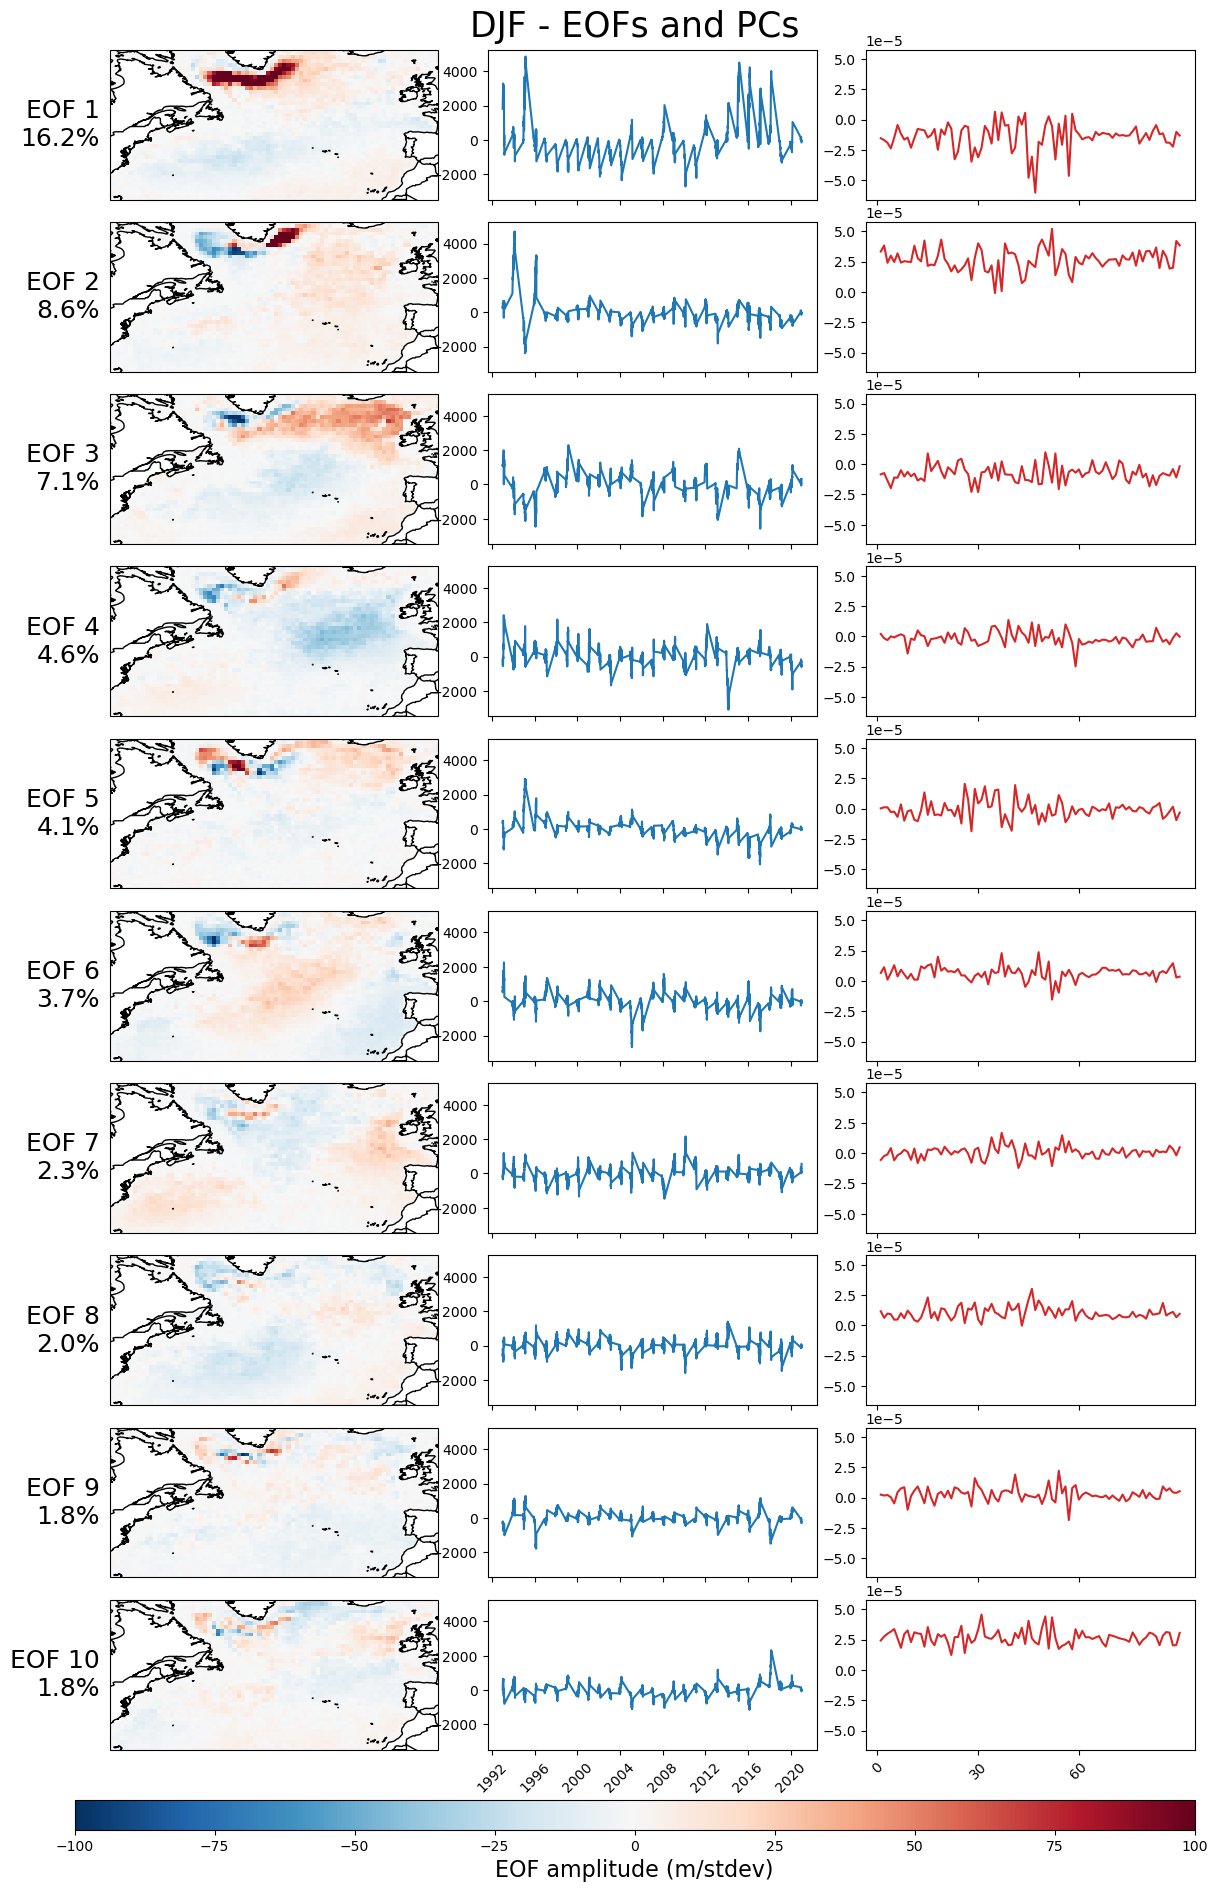

In [181]:
plot_seasonal_eofs(
    season_name="DJF",
    anom_data=DJF_anomalies,   # your seasonal anomalies DataArray
    eofs=DJF_eof,              # EOF maps for that season
    pcs=DJF_pcs,               # PC time series for that season
    explained_var=DJF_var,     # variance fraction for each EOF
    save_path= "DJF EOF+PC")

## CLUSTER ANALYSIS
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Cluster analysis function

In [36]:
from sklearn.cluster import KMeans
import numpy as np

def cluster_analysis(dataset_name, pcs, eofs, n_clusters=4, max_iter=500, n_init=500, random_state=42):
    """
    Perform K-means clustering on a given dataset's PCs and reconstruct cluster spatial patterns.

    Parameters
    ----------
    dataset_name : str
        Name of the dataset (for printing progress), e.g., 'DJF', 'full', etc.
    pcs : ndarray (time, n_EOF)
        Principal components for each time step of the dataset.
    eofs : ndarray (n_EOF, lat, lon)
        EOF spatial patterns corresponding to the PCs.
    n_clusters : int, default=4
        Number of clusters for KMeans.
    max_iter : int, default=500
        Maximum iterations per KMeans run.
    n_init : int, default=500
        Number of random initializations for KMeans.
    random_state : int, default=42
        Random state for reproducibility.

    Returns
    -------
    labels : ndarray (time,)
        Cluster assignment for each time step.
    centroids : ndarray (n_clusters, n_EOF)
        PC values representing each cluster.
    cluster_patterns : ndarray (n_clusters, lat, lon)
        Reconstructed spatial patterns of each cluster.
    """
    
    print(f"\n--- Starting K-means clustering for {dataset_name} ---")
    print(f"Number of clusters: {n_clusters}")
    print(f"PCs shape (time, n_EOF): {pcs.shape}")

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=max_iter, random_state=random_state)
    kmeans.fit(pcs)

    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_

    print("Clustering completed!")
    print(f"Cluster counts (number of time steps per cluster): {np.bincount(labels)}")

    # Reconstruct cluster spatial patterns
    n_clusters_actual = centroids.shape[0]
    n_lat, n_lon = eofs.shape[1], eofs.shape[2]
    cluster_patterns = np.zeros((n_clusters_actual, n_lat, n_lon))

    print("Reconstructing cluster spatial patterns from EOFs...")
    for i in range(n_clusters_actual):
        cluster_patterns[i] = np.tensordot(centroids[i], eofs, axes=([0],[0]))
    print("Cluster spatial patterns reconstructed.\n")

    return labels, centroids, cluster_patterns, dataset_name

#### Call cluster analysis function

In [185]:
labels, centroids, cluster_patterns, dataset_name = cluster_analysis(
    dataset_name="DJF",
    pcs=MAM_pcs,
    eofs=MAM_eof,
    n_clusters=4)



--- Starting K-means clustering for DJF ---
Number of clusters: 4
PCs shape (time, n_EOF): (2576, 10)
Clustering completed!
Cluster counts (number of time steps per cluster): [ 326  521   80 1649]
Reconstructing cluster spatial patterns from EOFs...
Cluster spatial patterns reconstructed.



#### Occupation frequency of each cluster

In [186]:
# ----------------------------------
# How often does each regime occur?
# ----------------------------------
ncluster = centroids.shape[0]

ratios = np.full(ncluster, np.nan)
for i in range(ncluster):
    ratios[i] = 100 * np.sum(labels == i) / len(labels)
print("Occupation frequency (%):", ratios)

# ----------------------------------
# Sort regimes by frequency : list regimes from most to least frequent (using original IDs)
# ----------------------------------
ratios_sorted = np.sort(ratios)[::-1]
idx_ratio_sort = np.argsort(ratios)[::-1]
print("Clusters ranked by frequency (most → least):", idx_ratio_sort)

# ----------------------------------
# Relabel clusters so IDs match frequency rank
# ----------------------------------
new_labels = np.full(labels.shape, np.nan)
new_centroids = np.full(centroids.shape, np.nan)
new_cluster_patterns = np.full(cluster_patterns.shape, np.nan)

for i in range(ncluster):
    # new ID = rank in frequency ordering
    new_id = int(np.where(idx_ratio_sort == i)[0][0])

    # relabel time series
    new_labels[labels == i] = new_id

    # reorder centroids and spatial patterns
    new_centroids[new_id] = centroids[i]
    new_cluster_patterns[new_id] = cluster_patterns[i]

labels = new_labels.astype(int)
centroids = new_centroids
cluster_patterns = new_cluster_patterns

# ----------------------------------
# Reorder ratios to match new IDs
# ----------------------------------
ratios_sorted = ratios[idx_ratio_sort]
print("Sorted occupation frequency (%):", ratios_sorted)

# ----------------------------------
# Check
# ----------------------------------
print("Counts after relabelling:", np.bincount(labels))

Occupation frequency (%): [12.6552795  20.22515528  3.10559006 64.01397516]
Clusters ranked by frequency (most → least): [3 1 0 2]
Sorted occupation frequency (%): [64.01397516 20.22515528 12.6552795   3.10559006]
Counts after relabelling: [1649  521  326   80]


## Plotting the centroids
<hr style="border: solid 2px blue; margin-top: 1.5% ">

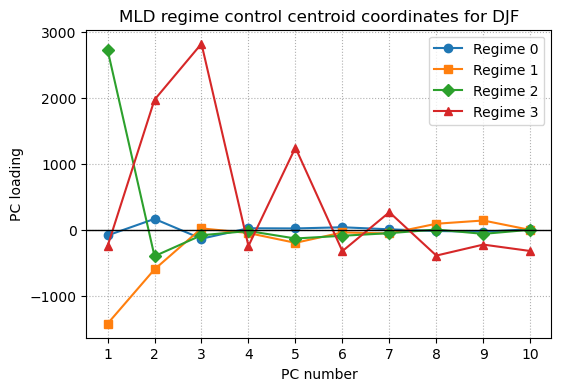

In [187]:
regnames = [f"Regime {i}" for i in range(ncluster)]
regcols = ['tab:blue','tab:orange','tab:green','tab:red']
markers = ['o','s','D','^']

x = np.arange(1, centroids.shape[1] + 1)

plt.figure(figsize=(6,4))
for r in range(ncluster):
    plt.plot(x, centroids[r],
             color=regcols[r],
             marker=markers[r],
             label=regnames[r])

plt.axhline(0, color='k', lw=1)
plt.grid(ls=':')
plt.xticks(x)
plt.xlabel("PC number")
plt.ylabel("PC loading")
plt.title(f"MLD regime control centroid coordinates for {dataset_name}")
plt.legend()
plt.savefig(f"Centroids {dataset_name}.png", dpi=300, bbox_inches="tight")
plt.show()

In [189]:
# Convert times to strings
anom_data = DJF_anomalies
regtime = anom_data.time.values # or full_anomalies.time.values

regtime = pd.to_datetime(regtime)
time_strs = regtime.strftime('%Y-%m-%d').tolist()
cluster_df = pd.DataFrame(labels, index=time_strs, dtype='int')

# cluster_df.to_csv('mlr_regimes_1993_2021.txt', sep=' ', index=True, header=False)


ValueError: Shape of passed values is (2576, 1), indices imply (2520, 1)

## Composites
<hr style="border: solid 2px blue; margin-top: 1.5% ">

#### Compute regime composites

In [190]:
regime_composite = np.full((ncluster, anom_data.shape[1], anom_data.shape[2]), np.nan)

for r in range(ncluster):
    subset = np.where(labels == r)[0]  # indices of times in regime r
    regime_composite[r] = np.mean(anom_data[subset], axis=0)

IndexError: index 2520 is out of bounds for axis 0 with size 2520

#### Define map extent

In [ ]:
def make_boundary_path(minlon,maxlon,minlat,maxlat,n=50):
    '''
    return a matplotlib Path whose points are a lon-lat box given by
    the input parameters
    '''
    boundary_path = []
    #North (E->W)
    edge = [np.linspace(minlon,maxlon,n), np.full(n,maxlat)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #West (N->S)
    edge = [np.full(n,maxlon),np.linspace(maxlat,minlat,n)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #South (W->E)
    edge = [np.linspace(maxlon,minlon,n), np.full(n,minlat)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    #East (S->N)
    edge = [np.full(n,minlon),np.linspace(minlat,maxlat,n)]
    boundary_path += [[i,j] for i,j in zip(*edge)]
    boundary_path = mpath.Path(boundary_path)
    return boundary_path

#### Mapping

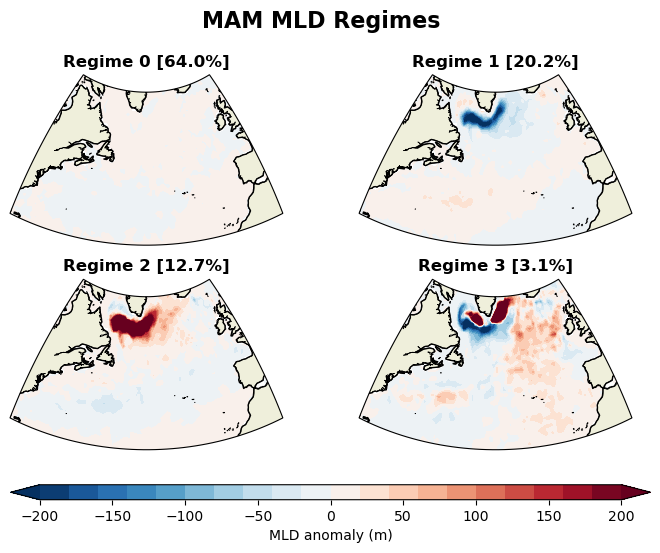

In [132]:
# -------------------------------
# Set contour levels for MLD
# -------------------------------
FIXED_VMAX = 200
vmax = FIXED_VMAX
clevs = np.linspace(-vmax, vmax, 21)
cticks = np.linspace(-vmax, vmax, 9)


# -------------------------------
# Define lat/lon arrays from your data
# -------------------------------
lons = anom_data.longitude.values
lats = anom_data.latitude.values

# -------------------------------
# Map extent
# -------------------------------
extent = [np.min(lons), np.max(lons), np.min(lats), np.max(lats)]

# -------------------------------
# Plot composites
# -------------------------------
fig, axs = plt.subplots(2, 2, figsize=(8,5),
                        subplot_kw={'projection': ccrs.LambertAzimuthalEqualArea(
                            central_longitude=np.median(lons),
                            central_latitude=np.median(lats))})

# Manually adjust layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.1, wspace=0.2, hspace=0.2)

# Add figure title
fig.suptitle(f"{dataset_name} MLD Regimes", fontsize=16, weight='bold')

for a, ax in enumerate(axs.reshape(-1)):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    boundary = make_boundary_path(*extent)
    ax.set_boundary(boundary, transform=ccrs.PlateCarree())

    cf = ax.contourf(lons, lats, regime_composite[a],
                     cmap='RdBu_r', levels=clevs, extend='both',
                     transform=ccrs.PlateCarree())

    ax.coastlines(color='k', resolution='50m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')
    ax.set_title(f"{regnames[a]} [{ratios_sorted[a]:.1f}%]", weight="bold")

# -------------------------------
# Horizontal colorbar
# -------------------------------
cb_ax = fig.add_axes([0.112, 0, 0.8, 0.03])
cbar = fig.colorbar(cf, cax=cb_ax, orientation="horizontal",
                    ticks=cticks, extend="both", spacing='proportional')
cbar.set_label("MLD anomaly (m)")

plt.savefig(f"Regimes {dataset_name}.png", dpi=300, bbox_inches="tight")
plt.show()


## MLD Regime Index
<hr style="border: solid 2px blue; margin-top: 1.5% ">

 #### Compute projections onto the composites

In [153]:
weights_ir = np.cos(np.radians(lats))
projection = np.full((ncluster, anom_data.shape[0]), np.nan)

for r in range(ncluster):
    reg_flat = regime_composite[r].flatten()
    for d in range(anom_data.shape[0]):
        day_array = anom_data[d].to_numpy()
        day_flat = (day_array * weights_ir[:, np.newaxis]).flatten()

        # Mask NaNs in either vector
        mask = np.isfinite(day_flat) & np.isfinite(reg_flat)
        if mask.sum() > 0:
            projection[r, d] = np.dot(day_flat[mask], reg_flat[mask])
        else:
            projection[r, d] = np.nan  # no valid data for this day

# Normalize
mean_proj = np.nanmean(projection, axis=1)
std_dev_proj = np.nanstd(projection, axis=1)
std_dev_proj_safe = np.where(std_dev_proj == 0, 1, std_dev_proj)
IR = (projection - mean_proj[:, np.newaxis]) / std_dev_proj_safe[:, np.newaxis]

#### Define function for time selection

In [154]:
# Ensure regtime is a datetime array
regtime = np.array([datetime(t.year, t.month, t.day) for t in regtime])

# Example: define start/end for DJF of a given year
def get_season_indices(regtime, season, year):
    """
    Return start/end indices for a given season in a given year.
    Season can be: 'DJF', 'MAM', 'JJA', 'SON', or 'full'.
    """
    if season.upper() == 'DJF':
        start_date = datetime(year, 12, 1)
        end_date   = datetime(year+1, 2, 28)
    elif season.upper() == 'MAM':
        start_date = datetime(year, 3, 1)
        end_date   = datetime(year, 5, 31)
    elif season.upper() == 'JJA':
        start_date = datetime(year, 6, 1)
        end_date   = datetime(year, 8, 31)
    elif season.upper() == 'SON':
        start_date = datetime(year, 9, 1)
        end_date   = datetime(year, 11, 30)
    elif season.lower() == 'full':
        start_date = regtime[0]
        end_date   = regtime[-1]
    else:
        raise ValueError("Season not recognized")

    # Find closest indices in regtime
    date_start = np.searchsorted(regtime, start_date)
    date_end   = np.searchsorted(regtime, end_date, side='right') - 1

    # Clip to dataset bounds
    date_start = max(0, min(date_start, len(regtime)-1))
    date_end   = max(0, min(date_end, len(regtime)-1))

    if date_start > date_end:
        raise ValueError(f"No data available for {season} {year}")

    return date_start, date_end

#### Define plotting function

In [159]:
def IR_plot(date_start, date_end, dataset_name):
    time_plot = regtime[date_start:date_end+1]
    assigned_regimes = labels[date_start:date_end+1]

    fig, ax = plt.subplots(figsize=(12,6))

    for r in range(ncluster):
        ax.plot(time_plot, IR[r, date_start:date_end+1].T, color=regcols[r])
        ax.plot(time_plot, np.ma.masked_less(IR[r, date_start:date_end+1].T, 1),
                marker=markers[r], color=regcols[r], linestyle='', label=regnames[r])
        
    for d in range(len(assigned_regimes)):
        ax.scatter(time_plot[d], 4.2 + 0.15*assigned_regimes[d],
                   marker=markers[int(assigned_regimes[d])],
                   color=regcols[int(assigned_regimes[d])])

    ax.legend(loc='lower center', ncol=ncluster)
    ax.grid(linestyle=':')
    ax.axhline(0, color='k', linewidth=1)
    ax.axhline(4, color='k', linewidth=1)
    ax.set_ylim(-4, 4.8)
    ax.set_ylabel("MLD regime index ($\sigma$)", weight="bold")

    # Only set x-limits and ticks if more than one day
    if len(time_plot) > 1:
        ax.set_xlim(time_plot[0], time_plot[-1])
        ticklab_subset = np.array([t.day in [1, 15] for t in time_plot])
        xticklabs = np.array([datetime.strftime(t, "%-d %b %Y") for t in time_plot[ticklab_subset]])
        ax.set_xticks(time_plot[ticklab_subset])
        ax.set_xticklabels(xticklabs, rotation=90, fontsize=9)

    # Dynamic title
    if season is not None and year is not None:
        if season.upper() == 'DJF':
            title_years = f"{year}-{year+1}"
        else:
            title_years = f"{year}"
        fig.suptitle(f"{season.upper()} MLD Regimes IR ({title_years})", fontsize=16, weight='bold')
    else:
        fig.suptitle("MLD Regime Index", fontsize=16, weight='bold')

    # -------------------------------
    # Save figure 
    # -------------------------------
    save_fname = f"Regime Index {dataset_name}.png"
    plt.savefig(save_fname, dpi=300, bbox_inches="tight")
    print(f"Figure saved as {save_fname}")

    return fig


#### Plot

Figure saved as Regime Index MAM.png


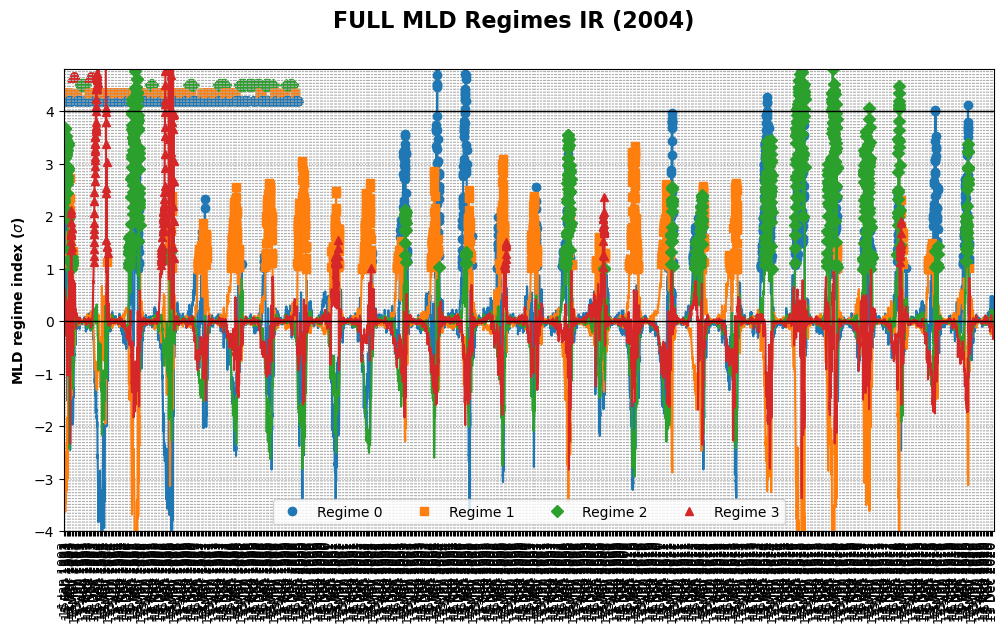

In [184]:
season = 'full'
year = 2004
date_start, date_end = get_season_indices(regtime, season, year)

fig = IR_plot(date_start, date_end, dataset_name)
plt.show()

In [140]:
print("projection shape:", projection.shape)
print("projection sample (first 10 days, first cluster):")
print(projection[0, :10])
print("projection min/max:", np.nanmin(projection), np.nanmax(projection))


projection shape: (4, 10220)
projection sample (first 10 days, first cluster):
[nan nan nan nan nan nan nan nan nan nan]
projection min/max: nan nan


/tmp/ipykernel_549/3923538642.py:4: RuntimeWarning: All-NaN slice encountered
  print("projection min/max:", np.nanmin(projection), np.nanmax(projection))
